# Movie Recommendation System
## Content-Based Filtering menggunakan Universal Sentence Encoder

**Deskripsi**: Sistem rekomendasi film berbasis semantic similarity menggunakan plot synopsis.

**Teknologi**:
- Universal Sentence Encoder (TensorFlow Hub)
- Cosine Similarity untuk ranking
- Dataset: MPST (Movie Plot Synopsis & Tags)

**Pipeline**:
1. Data Loading & Exploration
2. Data Cleaning & Validation
3. Embedding Generation
4. Model Evaluation
5. Recommendation System

---

## 1. Setup & Configuration

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import time
import os
import logging
import zipfile
from typing import Tuple, List, Optional
from tqdm import tqdm
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# Suppress TF warnings
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'

# Setup logging
logging.basicConfig(
    level=logging.INFO,
    format='%(asctime)s - %(levelname)s - %(message)s'
)
logger = logging.getLogger(__name__)

# Set random seeds for reproducibility
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

print("Imports complete.")

D:\conda\Lib\site-packages\tensorflow_hub\__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version



Imports complete.


In [2]:
class Config:
    """Configuration class untuk semua hyperparameters dan paths"""
    
    # Paths
    DATA_ZIP = 'mpst_full_data.csv.zip'
    DATA_CSV = 'mpst_full_data.csv'
    OUTPUT_EMBEDDINGS = 'movie_embeddings.npy'
    OUTPUT_METADATA = 'movies_clean.csv'
    CHECKPOINT_FILE = 'encoding_checkpoint.npz'
    
    # Model
    MODEL_URL = "https://tfhub.dev/google/universal-sentence-encoder/4"
    EMBEDDING_DIM = 512
    
    # Processing
    MIN_SYNOPSIS_LENGTH = 50  # Minimum karakter untuk synopsis yang valid
    MAX_SYNOPSIS_LENGTH = 10000  # Maximum karakter
    
    # Batch processing
    BATCH_SIZE = 128  # Default, akan disesuaikan dengan GPU/CPU
    CHECKPOINT_INTERVAL = 10  # Save checkpoint setiap N batch
    
    # Recommendation
    DEFAULT_TOP_K = 10
    SIMILARITY_THRESHOLD = 0.3  # Minimum similarity untuk dianggap relevan

config = Config()

# Detect GPU dan adjust batch size
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    logger.info(f"GPU detected: {gpus[0].name}")
    config.BATCH_SIZE = 256
    # Enable memory growth untuk prevent OOM
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
else:
    logger.info("Running on CPU")
    config.BATCH_SIZE = 64

logger.info(f"Batch size set to: {config.BATCH_SIZE}")

2026-02-01 00:57:00,712 - INFO - Running on CPU
2026-02-01 00:57:00,713 - INFO - Batch size set to: 64


## 2. Exploratory Data Analysis (EDA)

In [3]:
def load_raw_data(zip_path: str, csv_path: str) -> pd.DataFrame:
    """
    Load data dari zip atau CSV jika sudah di-extract
    
    Args:
        zip_path: Path ke file zip
        csv_path: Path ke file CSV
    
    Returns:
        DataFrame dengan data mentah
    """
    if not os.path.exists(csv_path):
        if not os.path.exists(zip_path):
            raise FileNotFoundError(f"Data source not found: {zip_path}")
        
        logger.info(f"Extracting {zip_path}...")
        with zipfile.ZipFile(zip_path, 'r') as zip_ref:
            zip_ref.extractall('.')
        logger.info("Extraction complete.")
    else:
        logger.info(f"CSV file already exists: {csv_path}")
    
    logger.info(f"Loading dataset from {csv_path}...")
    df = pd.read_csv(csv_path)
    logger.info(f"Dataset loaded. Shape: {df.shape}")
    
    return df

# Load data
df_raw = load_raw_data(config.DATA_ZIP, config.DATA_CSV)
df_raw.head(3)

2026-02-01 00:57:06,594 - INFO - CSV file already exists: mpst_full_data.csv
2026-02-01 00:57:06,595 - INFO - Loading dataset from mpst_full_data.csv...
2026-02-01 00:57:07,364 - INFO - Dataset loaded. Shape: (14828, 6)


,imdb_id,title,plot_synopsis,tags,split,synopsis_source
0,tt0057603,I tre volti della paura,Note: this synopsis is for the orginal Italian...,"cult, horror, gothic, murder, atmospheric",train,imdb
1,tt1733125,Dungeons & Dragons: The Book of Vile Darkness,"Two thousand years ago, Nhagruul the Foul, a s...",violence,train,imdb
2,tt0033045,The Shop Around the Corner,"Matuschek's, a gift store in Budapest, is the ...",romantic,test,imdb


In [4]:
# Basic information
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total records: {len(df_raw):,}")
print(f"Total columns: {len(df_raw.columns)}")
print(f"\nColumns: {df_raw.columns.tolist()}")
print("\n" + "=" * 60)
print("DATA TYPES")
print("=" * 60)
print(df_raw.dtypes)
print("\n" + "=" * 60)
print("MISSING VALUES")
print("=" * 60)
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Percentage': missing_pct
})
print(missing_df[missing_df['Missing Count'] > 0])

DATASET OVERVIEW
Total records: 14,828
Total columns: 6

Columns: ['imdb_id', 'title', 'plot_synopsis', 'tags', 'split', 'synopsis_source']

DATA TYPES
imdb_id            object
title              object
plot_synopsis      object
tags               object
split              object
synopsis_source    object
dtype: object

MISSING VALUES
Empty DataFrame
Columns: [Missing Count, Percentage]
Index: []


In [5]:
# Analyze synopsis quality
print("=" * 60)
print("PLOT SYNOPSIS ANALYSIS")
print("=" * 60)

# Length statistics
synopsis_lengths = df_raw['plot_synopsis'].dropna().str.len()
print("\nLength Statistics:")
print(synopsis_lengths.describe())

# Check for duplicates
duplicate_titles = df_raw['title'].duplicated().sum()
duplicate_synopsis = df_raw['plot_synopsis'].dropna().duplicated().sum()
print(f"\nDuplicate titles: {duplicate_titles:,}")
print(f"Duplicate synopsis: {duplicate_synopsis:,}")

# Check for very short/long synopsis
very_short = (synopsis_lengths < 50).sum()
very_long = (synopsis_lengths > 10000).sum()
print(f"\nVery short synopsis (<50 chars): {very_short:,}")
print(f"Very long synopsis (>10k chars): {very_long:,}")

PLOT SYNOPSIS ANALYSIS

Length Statistics:
count    14828.000000
mean      5139.938090
std       4939.950638
min        442.000000
25%       2494.750000
50%       3827.000000
75%       5760.000000
max      63959.000000
Name: plot_synopsis, dtype: float64

Duplicate titles: 1,071
Duplicate synopsis: 980

Very short synopsis (<50 chars): 0
Very long synopsis (>10k chars): 1,396


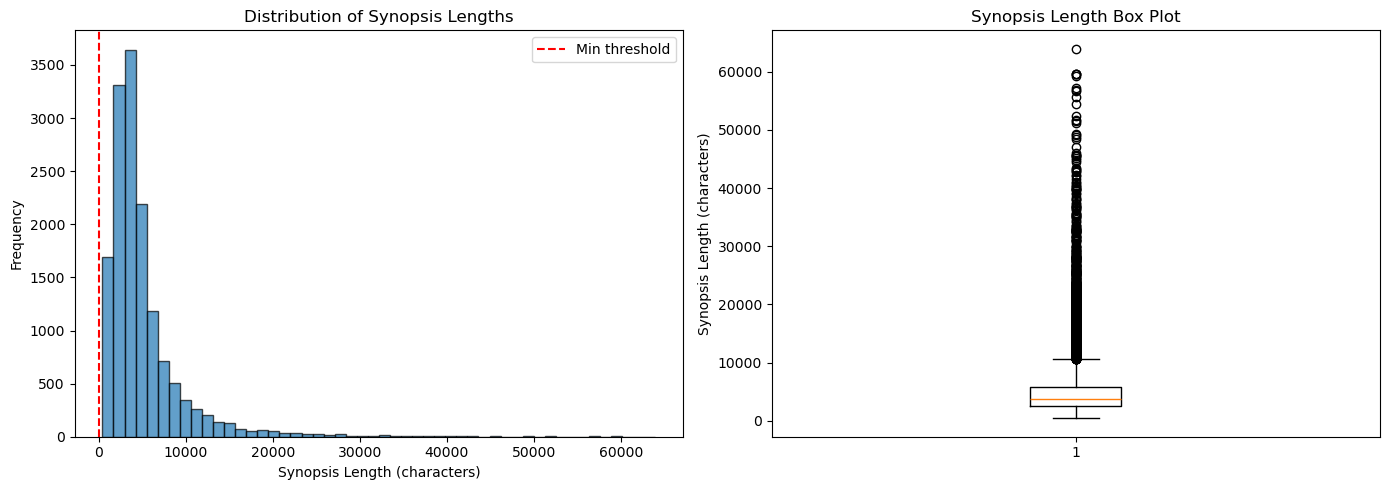


Visualization complete. Median length: 3827 characters


In [6]:
# Visualize synopsis length distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(synopsis_lengths, bins=50, edgecolor='black', alpha=0.7)
axes[0].set_xlabel('Synopsis Length (characters)')
axes[0].set_ylabel('Frequency')
axes[0].set_title('Distribution of Synopsis Lengths')
axes[0].axvline(config.MIN_SYNOPSIS_LENGTH, color='red', linestyle='--', label='Min threshold')
axes[0].legend()

# Box plot
axes[1].boxplot(synopsis_lengths)
axes[1].set_ylabel('Synopsis Length (characters)')
axes[1].set_title('Synopsis Length Box Plot')

plt.tight_layout()
plt.show()

print(f"\nVisualization complete. Median length: {synopsis_lengths.median():.0f} characters")

## 3. Data Cleaning & Validation

In [7]:
def clean_and_validate_data(df: pd.DataFrame, min_length: int, max_length: int) -> pd.DataFrame:
    """
    Comprehensive data cleaning dengan validasi
    
    Args:
        df: Raw dataframe
        min_length: Minimum panjang synopsis yang diterima
        max_length: Maximum panjang synopsis yang diterima
    
    Returns:
        Cleaned dataframe
    """
    logger.info("Starting data cleaning pipeline...")
    initial_count = len(df)
    
    # Step 1: Select relevant columns
    df_clean = df[['title', 'plot_synopsis']].copy()
    logger.info(f"Selected columns: {df_clean.columns.tolist()}")
    
    # Step 2: Remove missing values
    before_dropna = len(df_clean)
    df_clean.dropna(inplace=True)
    dropped_na = before_dropna - len(df_clean)
    logger.info(f"Removed {dropped_na:,} rows with missing values")
    
    # Step 3: Strip whitespace
    df_clean['title'] = df_clean['title'].str.strip()
    df_clean['plot_synopsis'] = df_clean['plot_synopsis'].str.strip()
    
    # Step 4: Filter by length
    before_length_filter = len(df_clean)
    synopsis_lengths = df_clean['plot_synopsis'].str.len()
    df_clean = df_clean[
        (synopsis_lengths >= min_length) & 
        (synopsis_lengths <= max_length)
    ].copy()
    dropped_length = before_length_filter - len(df_clean)
    logger.info(f"Removed {dropped_length:,} rows with invalid synopsis length")
    
    # Step 5: Remove duplicates
    before_dedup = len(df_clean)
    df_clean.drop_duplicates(subset=['title'], keep='first', inplace=True)
    dropped_dup_title = before_dedup - len(df_clean)
    logger.info(f"Removed {dropped_dup_title:,} duplicate titles")
    
    # Step 6: Remove duplicate synopsis (same plot, different title)
    before_dedup_synopsis = len(df_clean)
    df_clean.drop_duplicates(subset=['plot_synopsis'], keep='first', inplace=True)
    dropped_dup_synopsis = before_dedup_synopsis - len(df_clean)
    logger.info(f"Removed {dropped_dup_synopsis:,} duplicate synopsis")
    
    # Step 7: Reset index
    df_clean.reset_index(drop=True, inplace=True)
    
    # Summary
    final_count = len(df_clean)
    total_dropped = initial_count - final_count
    retention_rate = (final_count / initial_count * 100)
    
    logger.info("=" * 60)
    logger.info("DATA CLEANING SUMMARY")
    logger.info("=" * 60)
    logger.info(f"Initial records: {initial_count:,}")
    logger.info(f"Final records: {final_count:,}")
    logger.info(f"Total dropped: {total_dropped:,}")
    logger.info(f"Retention rate: {retention_rate:.2f}%")
    logger.info("=" * 60)
    
    return df_clean

# Execute cleaning
df_clean = clean_and_validate_data(
    df_raw, 
    config.MIN_SYNOPSIS_LENGTH, 
    config.MAX_SYNOPSIS_LENGTH
)

print("\nSample of cleaned data:")
df_clean.head()

2026-02-01 00:57:30,684 - INFO - Starting data cleaning pipeline...
2026-02-01 00:57:30,687 - INFO - Selected columns: ['title', 'plot_synopsis']
2026-02-01 00:57:30,690 - INFO - Removed 0 rows with missing values
2026-02-01 00:57:30,707 - INFO - Removed 1,396 rows with invalid synopsis length
2026-02-01 00:57:30,710 - INFO - Removed 874 duplicate titles
2026-02-01 00:57:30,714 - INFO - Removed 302 duplicate synopsis
2026-02-01 00:57:30,714 - INFO - ============================================================
2026-02-01 00:57:30,715 - INFO - DATA CLEANING SUMMARY
2026-02-01 00:57:30,715 - INFO - ============================================================
2026-02-01 00:57:30,716 - INFO - Initial records: 14,828
2026-02-01 00:57:30,716 - INFO - Final records: 12,256
2026-02-01 00:57:30,717 - INFO - Total dropped: 2,572
2026-02-01 00:57:30,717 - INFO - Retention rate: 82.65%
2026-02-01 00:57:30,718 - INFO - ============================================================



Sample of cleaned data:


,title,plot_synopsis
0,I tre volti della paura,Note: this synopsis is for the orginal Italian...
1,Dungeons & Dragons: The Book of Vile Darkness,"Two thousand years ago, Nhagruul the Foul, a s..."
2,The Shop Around the Corner,"Matuschek's, a gift store in Budapest, is the ..."
3,A Single Man,George Falconer (Colin Firth) approaches a car...
4,Baise-moi,Baise-moi tells the story of Nadine and Manu w...


In [8]:
# Validation: Verify no issues remain
print("=" * 60)
print("POST-CLEANING VALIDATION")
print("=" * 60)
print(f"No missing values: {df_clean.isnull().sum().sum() == 0}")
print(f"No duplicate titles: {df_clean['title'].duplicated().sum() == 0}")
print(f"No duplicate synopsis: {df_clean['plot_synopsis'].duplicated().sum() == 0}")

lengths = df_clean['plot_synopsis'].str.len()
print(f"Min length >= {config.MIN_SYNOPSIS_LENGTH}: {lengths.min() >= config.MIN_SYNOPSIS_LENGTH}")
print(f"Max length <= {config.MAX_SYNOPSIS_LENGTH}: {lengths.max() <= config.MAX_SYNOPSIS_LENGTH}")
print("\nAll validation checks passed!" if all([
    df_clean.isnull().sum().sum() == 0,
    df_clean['title'].duplicated().sum() == 0,
    lengths.min() >= config.MIN_SYNOPSIS_LENGTH
]) else "\nWarning: Some validation checks failed!")

POST-CLEANING VALIDATION
No missing values: True
No duplicate titles: True
No duplicate synopsis: True
Min length >= 50: True
Max length <= 10000: True

All validation checks passed!


## 4. Embedding Generation

In [9]:
def load_encoder(model_url: str):
    """
    Load Universal Sentence Encoder dengan error handling
    
    Args:
        model_url: TensorFlow Hub URL
    
    Returns:
        Loaded model
    """
    logger.info(f"Loading model from {model_url}")
    logger.info("This may take a few minutes on first run...")
    
    try:
        start_time = time.time()
        model = hub.load(model_url)
        load_time = time.time() - start_time
        logger.info(f"Model loaded successfully in {load_time:.2f} seconds")
        return model
    except Exception as e:
        logger.error(f"Failed to load model: {str(e)}")
        raise RuntimeError(f"Model loading failed. Error: {str(e)}")

# Load model
encoder = load_encoder(config.MODEL_URL)

2026-02-01 00:57:55,041 - INFO - Loading model from https://tfhub.dev/google/universal-sentence-encoder/4
2026-02-01 00:57:55,041 - INFO - This may take a few minutes on first run...
2026-02-01 00:57:55,042 - INFO - Using C:\Users\WENDRI~1\AppData\Local\Temp\tfhub_modules to cache modules.


2026-02-01 00:57:55,180 - WARNING - From D:\conda\Lib\site-packages\tensorflow_hub\resolver.py:120: The name tf.gfile.MakeDirs is deprecated. Please use tf.io.gfile.makedirs instead.



2026-02-01 00:57:55,239 - WARNING - From D:\conda\Lib\site-packages\tensorflow_hub\module_v2.py:126: The name tf.saved_model.load_v2 is deprecated. Please use tf.compat.v2.saved_model.load instead.

2026-02-01 00:58:00,186 - INFO - Fingerprint not found. Saved model loading will continue.
2026-02-01 00:58:00,186 - INFO - path_and_singleprint metric could not be logged. Saved model loading will continue.
2026-02-01 00:58:00,187 - INFO - Model loaded successfully in 5.15 seconds


In [10]:
def encode_texts_with_checkpoint(
    model, 
    texts: List[str], 
    batch_size: int,
    checkpoint_file: str,
    checkpoint_interval: int = 10
) -> np.ndarray:
    """
    Encode texts dengan checkpoint untuk recovery
    
    Args:
        model: TensorFlow Hub model
        texts: List of text to encode
        batch_size: Batch size untuk processing
        checkpoint_file: Path untuk save checkpoint
        checkpoint_interval: Save checkpoint setiap N batch
    
    Returns:
        Numpy array of embeddings (N x 512)
    """
    total_records = len(texts)
    embeddings_list = []
    start_idx = 0
    
    # Check for existing checkpoint
    if os.path.exists(checkpoint_file):
        logger.info(f"Found checkpoint file: {checkpoint_file}")
        user_input = input("Resume from checkpoint? (y/n): ")
        if user_input.lower() == 'y':
            checkpoint = np.load(checkpoint_file, allow_pickle=True)
            embeddings_list = checkpoint['embeddings'].tolist()
            start_idx = checkpoint['last_index'].item()
            logger.info(f"Resuming from index {start_idx}")
    
    logger.info(f"Starting encoding from index {start_idx}/{total_records}")
    start_time = time.time()
    
    try:
        # Process batches
        batch_count = 0
        for i in tqdm(range(start_idx, total_records, batch_size), desc="Encoding batches"):
            batch = texts[i : i + batch_size]
            
            # Encode
            batch_embeddings = model(batch)
            embeddings_list.append(batch_embeddings.numpy())
            
            batch_count += 1
            
            # Save checkpoint
            if batch_count % checkpoint_interval == 0:
                np.savez(
                    checkpoint_file,
                    embeddings=np.vstack(embeddings_list),
                    last_index=i + batch_size
                )
                logger.info(f"Checkpoint saved at index {i + batch_size}")
        
        # Stack all embeddings
        final_embeddings = np.vstack(embeddings_list)
        
        # Calculate statistics
        elapsed_time = time.time() - start_time
        records_processed = total_records - start_idx
        speed = records_processed / elapsed_time
        
        logger.info("=" * 60)
        logger.info("ENCODING COMPLETE")
        logger.info("=" * 60)
        logger.info(f"Total records encoded: {records_processed:,}")
        logger.info(f"Output shape: {final_embeddings.shape}")
        logger.info(f"Time elapsed: {elapsed_time:.2f} seconds")
        logger.info(f"Speed: {speed:.2f} records/second")
        logger.info(f"Memory size: {final_embeddings.nbytes / (1024**2):.2f} MB")
        logger.info("=" * 60)
        
        # Clean up checkpoint
        if os.path.exists(checkpoint_file):
            os.remove(checkpoint_file)
            logger.info("Checkpoint file cleaned up")
        
        return final_embeddings
        
    except Exception as e:
        logger.error(f"Encoding failed: {str(e)}")
        logger.info(f"Checkpoint saved at {checkpoint_file} for recovery")
        raise

# Execute encoding
synopses = df_clean['plot_synopsis'].tolist()
embeddings = encode_texts_with_checkpoint(
    encoder, 
    synopses, 
    config.BATCH_SIZE,
    config.CHECKPOINT_FILE,
    config.CHECKPOINT_INTERVAL
)

2026-02-01 00:58:00,202 - INFO - Starting encoding from index 0/12256
Encoding batches: 100%|██████████████████████████████████████████████████████████████| 192/192 [00:23<00:00,  8.23it/s]
2026-02-01 00:58:23,539 - INFO - ============================================================
2026-02-01 00:58:23,540 - INFO - ENCODING COMPLETE
2026-02-01 00:58:23,541 - INFO - ============================================================
2026-02-01 00:58:23,541 - INFO - Total records encoded: 12,256
2026-02-01 00:58:23,542 - INFO - Output shape: (12256, 512)
2026-02-01 00:58:23,542 - INFO - Time elapsed: 23.34 seconds
2026-02-01 00:58:23,543 - INFO - Speed: 525.18 records/second
2026-02-01 00:58:23,543 - INFO - Memory size: 23.94 MB
2026-02-01 00:58:23,544 - INFO - ============================================================
2026-02-01 00:58:23,547 - INFO - Checkpoint file cleaned up


In [11]:
# Sanity check embeddings
print("=" * 60)
print("EMBEDDING SANITY CHECKS")
print("=" * 60)
print(f"Shape: {embeddings.shape}")
print(f"Expected: ({len(df_clean)}, {config.EMBEDDING_DIM})")
print(f"Shape matches: {embeddings.shape == (len(df_clean), config.EMBEDDING_DIM)}")
print(f"\nData type: {embeddings.dtype}")
print(f"No NaN values: {not np.isnan(embeddings).any()}")
print(f"No Inf values: {not np.isinf(embeddings).any()}")
print(f"\nValue range: [{embeddings.min():.4f}, {embeddings.max():.4f}]")
print(f"Mean: {embeddings.mean():.4f}")
print(f"Std: {embeddings.std():.4f}")

EMBEDDING SANITY CHECKS
Shape: (12256, 512)
Expected: (12256, 512)
Shape matches: True

Data type: float32
No NaN values: True
No Inf values: True

Value range: [-0.0869, 0.0869]
Mean: 0.0015
Std: 0.0442


## 5. Save Artifacts

In [12]:
def save_artifacts(
    embeddings: np.ndarray, 
    metadata: pd.DataFrame, 
    emb_file: str, 
    meta_file: str
) -> None:
    """
    Save embeddings dan metadata dengan validation
    
    Args:
        embeddings: Numpy array of embeddings
        metadata: DataFrame with movie metadata
        emb_file: Output path for embeddings
        meta_file: Output path for metadata
    """
    logger.info("Saving artifacts...")
    
    # Validate shape consistency
    if embeddings.shape[0] != len(metadata):
        raise ValueError(
            f"Shape mismatch: embeddings ({embeddings.shape[0]}) != metadata ({len(metadata)})"
        )
    
    # Save embeddings
    try:
        np.save(emb_file, embeddings)
        file_size = os.path.getsize(emb_file) / (1024**2)
        logger.info(f"Embeddings saved to {emb_file} ({file_size:.2f} MB)")
    except Exception as e:
        logger.error(f"Failed to save embeddings: {str(e)}")
        raise
    
    # Save metadata
    try:
        metadata.to_csv(meta_file, index=False)
        file_size = os.path.getsize(meta_file) / (1024**2)
        logger.info(f"Metadata saved to {meta_file} ({file_size:.2f} MB)")
    except Exception as e:
        logger.error(f"Failed to save metadata: {str(e)}")
        raise
    
    logger.info("All artifacts saved successfully")

# Save everything
save_artifacts(
    embeddings, 
    df_clean, 
    config.OUTPUT_EMBEDDINGS, 
    config.OUTPUT_METADATA
)

2026-02-01 00:58:36,138 - INFO - Saving artifacts...
2026-02-01 00:58:36,155 - INFO - Embeddings saved to movie_embeddings.npy (23.94 MB)
2026-02-01 00:58:36,663 - INFO - Metadata saved to movies_clean.csv (46.12 MB)
2026-02-01 00:58:36,664 - INFO - All artifacts saved successfully


In [13]:
# Verify saved files dapat di-load kembali
print("=" * 60)
print("VERIFYING SAVED FILES")
print("=" * 60)

try:
    loaded_embeddings = np.load(config.OUTPUT_EMBEDDINGS)
    loaded_metadata = pd.read_csv(config.OUTPUT_METADATA)
    
    print(f"Embeddings shape: {loaded_embeddings.shape}")
    print(f"Metadata rows: {len(loaded_metadata)}")
    print(f"Shapes match: {loaded_embeddings.shape[0] == len(loaded_metadata)}")
    print(f"\nArrays equal: {np.allclose(embeddings, loaded_embeddings)}")
    print(f"DataFrames equal: {df_clean.equals(loaded_metadata)}")
    print("\n✓ All verification checks passed!")
except Exception as e:
    print(f"✗ Verification failed: {str(e)}")

VERIFYING SAVED FILES
Embeddings shape: (12256, 512)
Metadata rows: 12256
Shapes match: True

Arrays equal: True
DataFrames equal: True

✓ All verification checks passed!


## 6. Model Evaluation

Sebelum deploy, kita perlu validasi bahwa model menghasilkan rekomendasi yang reasonable.

In [14]:
def calculate_similarity_matrix(embeddings: np.ndarray) -> np.ndarray:
    """
    Calculate pairwise cosine similarity
    Warning: Memory intensive untuk dataset besar
    
    Args:
        embeddings: Embedding matrix (N x D)
    
    Returns:
        Similarity matrix (N x N)
    """
    logger.info("Calculating similarity matrix (this may take a while)...")
    similarity_matrix = cosine_similarity(embeddings)
    logger.info(f"Similarity matrix shape: {similarity_matrix.shape}")
    return similarity_matrix

# Calculate similarity (sample untuk efficiency)
# Untuk full dataset, gunakan approximate nearest neighbor (ANN)
sample_size = min(1000, len(embeddings))
sample_indices = np.random.choice(len(embeddings), sample_size, replace=False)
sample_embeddings = embeddings[sample_indices]

similarity_matrix_sample = calculate_similarity_matrix(sample_embeddings)

2026-02-01 00:58:50,755 - INFO - Calculating similarity matrix (this may take a while)...
2026-02-01 00:58:50,768 - INFO - Similarity matrix shape: (1000, 1000)


SIMILARITY DISTRIBUTION ANALYSIS
Total pairs analyzed: 499,500

Similarity Statistics:
Mean: 0.4406
Median: 0.4433
Std: 0.0885
Min: 0.0297
Max: 0.8954

Percentiles:
  25th: 0.3823
  50th: 0.4433
  75th: 0.5018
  90th: 0.5523
  95th: 0.5814
  99th: 0.6344


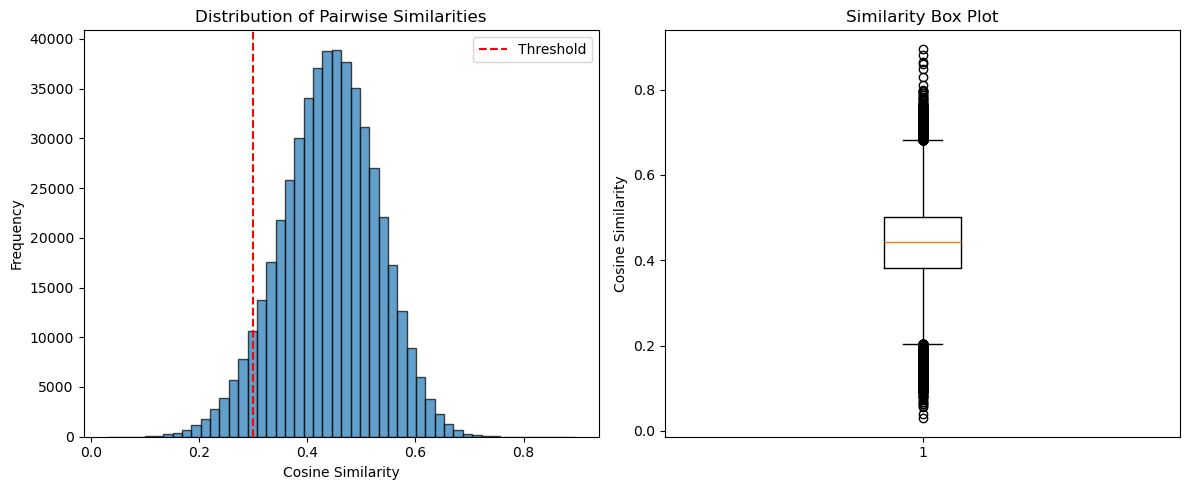

In [15]:
# Analyze similarity distribution
print("=" * 60)
print("SIMILARITY DISTRIBUTION ANALYSIS")
print("=" * 60)

# Get upper triangle (exclude diagonal)
upper_triangle = similarity_matrix_sample[np.triu_indices_from(similarity_matrix_sample, k=1)]

print(f"Total pairs analyzed: {len(upper_triangle):,}")
print(f"\nSimilarity Statistics:")
print(f"Mean: {upper_triangle.mean():.4f}")
print(f"Median: {np.median(upper_triangle):.4f}")
print(f"Std: {upper_triangle.std():.4f}")
print(f"Min: {upper_triangle.min():.4f}")
print(f"Max: {upper_triangle.max():.4f}")
print(f"\nPercentiles:")
for p in [25, 50, 75, 90, 95, 99]:
    print(f"  {p}th: {np.percentile(upper_triangle, p):.4f}")

# Visualize
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.hist(upper_triangle, bins=50, edgecolor='black', alpha=0.7)
plt.xlabel('Cosine Similarity')
plt.ylabel('Frequency')
plt.title('Distribution of Pairwise Similarities')
plt.axvline(config.SIMILARITY_THRESHOLD, color='red', linestyle='--', label='Threshold')
plt.legend()

plt.subplot(1, 2, 2)
plt.boxplot(upper_triangle)
plt.ylabel('Cosine Similarity')
plt.title('Similarity Box Plot')

plt.tight_layout()
plt.show()

In [16]:
# Check for potential issues
print("=" * 60)
print("QUALITY CHECKS")
print("=" * 60)

# Check for identical embeddings (should be rare)
identical_pairs = (upper_triangle > 0.99).sum()
print(f"Identical pairs (sim > 0.99): {identical_pairs} ({identical_pairs/len(upper_triangle)*100:.2f}%)")

# Check for very dissimilar pairs
very_dissimilar = (upper_triangle < 0.1).sum()
print(f"Very dissimilar pairs (sim < 0.1): {very_dissimilar} ({very_dissimilar/len(upper_triangle)*100:.2f}%)")

# Check recommendation coverage
relevant_pairs = (upper_triangle > config.SIMILARITY_THRESHOLD).sum()
print(f"Relevant pairs (sim > {config.SIMILARITY_THRESHOLD}): {relevant_pairs} ({relevant_pairs/len(upper_triangle)*100:.2f}%)")

if relevant_pairs / len(upper_triangle) < 0.01:
    print("\n⚠ WARNING: Very few relevant pairs. Consider lowering similarity threshold.")
elif relevant_pairs / len(upper_triangle) > 0.50:
    print("\n⚠ WARNING: Too many relevant pairs. Consider raising similarity threshold.")
else:
    print("\n✓ Recommendation coverage looks good!")

QUALITY CHECKS
Identical pairs (sim > 0.99): 0 (0.00%)
Very dissimilar pairs (sim < 0.1): 32 (0.01%)
Relevant pairs (sim > 0.3): 468739 (93.84%)

⚠ WARNING: Too many relevant pairs. Consider raising similarity threshold.


## 7. Recommendation System

In [17]:
class MovieRecommender:
    """
    Movie recommendation system dengan comprehensive features
    """
    
    def __init__(self, embeddings: np.ndarray, metadata: pd.DataFrame):
        """
        Initialize recommender
        
        Args:
            embeddings: Movie embeddings matrix
            metadata: Movie metadata dataframe
        """
        self.embeddings = embeddings
        self.metadata = metadata
        
        # Create title lookup dictionary (case-insensitive)
        self.title_to_idx = {
            title.lower(): idx 
            for idx, title in enumerate(metadata['title'])
        }
        
        logger.info(f"Recommender initialized with {len(metadata)} movies")
    
    def find_movie(self, query: str) -> Optional[Tuple[int, str]]:
        """
        Find movie index by title (case-insensitive)
        
        Args:
            query: Movie title to search
        
        Returns:
            Tuple of (index, exact_title) or None if not found
        """
        query_lower = query.lower().strip()
        
        # Exact match
        if query_lower in self.title_to_idx:
            idx = self.title_to_idx[query_lower]
            return idx, self.metadata.iloc[idx]['title']
        
        # Partial match
        matches = self.metadata[
            self.metadata['title'].str.lower().str.contains(query_lower, na=False)
        ]
        
        if len(matches) > 0:
            print(f"\nDid you mean one of these?")
            for i, row in matches.head(5).iterrows():
                print(f"  - {row['title']}")
            return None
        
        return None
    
    def get_recommendations(
        self, 
        query_title: str, 
        top_k: int = 10,
        min_similarity: float = 0.0
    ) -> Optional[pd.DataFrame]:
        """
        Get movie recommendations berdasarkan similarity
        
        Args:
            query_title: Title of query movie
            top_k: Number of recommendations to return
            min_similarity: Minimum similarity threshold
        
        Returns:
            DataFrame dengan recommendations atau None jika tidak ditemukan
        """
        # Validate input
        if not query_title or not query_title.strip():
            print("Error: Empty query string")
            return None
        
        # Find movie
        result = self.find_movie(query_title)
        if result is None:
            print(f"Movie '{query_title}' not found in database.")
            return None
        
        idx, exact_title = result
        
        # Calculate similarities
        target_vector = self.embeddings[idx].reshape(1, -1)
        similarity_scores = cosine_similarity(target_vector, self.embeddings).flatten()
        
        # Get top-k (excluding the query movie itself)
        # Sort descending and skip first (itself)
        sorted_indices = similarity_scores.argsort()[::-1]
        
        # Filter by minimum similarity and exclude query movie
        recommendations = []
        for i in sorted_indices:
            if i == idx:
                continue
            
            sim_score = similarity_scores[i]
            if sim_score < min_similarity:
                break
            
            recommendations.append({
                'rank': len(recommendations) + 1,
                'title': self.metadata.iloc[i]['title'],
                'similarity_score': sim_score,
                'similarity_pct': sim_score * 100,
                'plot_synopsis': self.metadata.iloc[i]['plot_synopsis']
            })
            
            if len(recommendations) >= top_k:
                break
        
        if not recommendations:
            print(f"No recommendations found with similarity >= {min_similarity}")
            return None
        
        results_df = pd.DataFrame(recommendations)
        
        # Print formatted results
        print("=" * 80)
        print(f"RECOMMENDATIONS FOR: '{exact_title}'")
        print("=" * 80)
        print(f"Query Synopsis: {self.metadata.iloc[idx]['plot_synopsis'][:200]}...\n")
        
        for _, row in results_df.iterrows():
            print(f"{row['rank']}. {row['title']}")
            print(f"   Similarity: {row['similarity_score']:.4f} ({row['similarity_pct']:.2f}%)")
            print(f"   Synopsis: {row['plot_synopsis'][:150]}...")
            print("-" * 80)
        
        return results_df
    
    def batch_recommendations(
        self, 
        query_titles: List[str], 
        top_k: int = 5
    ) -> dict:
        """
        Get recommendations untuk multiple movies sekaligus
        
        Args:
            query_titles: List of movie titles
            top_k: Number of recommendations per movie
        
        Returns:
            Dictionary mapping query title to recommendations
        """
        results = {}
        for title in query_titles:
            print(f"\nProcessing: {title}")
            recs = self.get_recommendations(title, top_k=top_k)
            results[title] = recs
        return results

# Initialize recommender
recommender = MovieRecommender(embeddings, df_clean)
print("Recommender ready!")

2026-02-01 00:59:09,280 - INFO - Recommender initialized with 12256 movies


Recommender ready!


## 8. Testing & Examples

In [ ]:
# Test Case 1: Popular movie
results = recommender.get_recommendations(
    query_title="titanic",
    top_k=5,
    min_similarity=0.3
)

In [ ]:
# Test Case 2: Animation movie
results = recommender.get_recommendations(
    query_title="bee movie",
    top_k=5,
    min_similarity=0.3
)

In [ ]:
# Test Case 3: Horror movie
results = recommender.get_recommendations(
    query_title="The Shining",
    top_k=5,
    min_similarity=0.3
)

In [ ]:
# Interactive test
print("Enter a movie title (or 'quit' to exit):")
while True:
    query = input("\n> ")
    if query.lower() in ['quit', 'exit', 'q']:
        break
    
    recommender.get_recommendations(query, top_k=5)

## 9. Next Steps & Improvements

### Immediate Improvements:
1. Implement Approximate Nearest Neighbor (ANN) untuk scalability
   - FAISS, Annoy, atau ScaNN
2. Add genre/tag filtering
3. Hybrid recommendation (content + collaborative)
4. A/B testing framework

### Production Deployment:
1. Deploy sebagai REST API (FastAPI/Flask)
2. Add caching layer (Redis)
3. Monitoring & logging (Prometheus/Grafana)
4. Model versioning (MLflow/DVC)

### Advanced Features:
1. Multi-lingual support
2. Temporal dynamics (newer movies prioritized)
3. User preference learning
4. Explanation generation